# Solitones en fibras ópticas: significado físico

¿Qué es un solitón? Un solitón es una onda que mantiene su forma y velocidad a lo largo del tiempo, incluso después de interactuar con otras ondas. En el contexto de las fibras ópticas, un solitón es un pulso de luz que se propaga sin dispersión ni distorsión, lo que lo hace ideal para la transmisión de información a largas distancias.

- Dispersión: En las fibras ópticas, la dispersión es el fenómeno por el cual diferentes componentes de un pulso de luz se propagan a diferentes velocidades, lo que puede causar que el pulso se ensanche y pierda su forma original. Un solitón, sin embargo, contrarresta esta dispersión mediante un equilibrio entre la no linealidad del medio y la dispersión, lo que le permite mantener su forma.

- No linealidad: La no linealidad en las fibras ópticas se refiere a la respuesta del medio a la intensidad de la luz. En un solitón, la no linealidad actúa para contrarrestar los efectos de la dispersión, permitiendo que el pulso mantenga su forma y velocidad.

## Interpretación en fibras ópticas

- u(x,t) representa la intensidad del pulso de luz en la fibra óptica en función de la posición x y el tiempo t.
- La fibra introduce:
    - Dispersión cromática
    - No linealidad (Índice de refracción dependiente de la intensidad)
- Bajo condiciones específicas, el equilibrio entre dispersión y no linealidad permite la formación de solitones, que pueden propagarse sin distorsión a lo largo de la fibra óptica.

¿Para qué sirve? 
- Transmisión de datos: Los solitones pueden ser utilizados para transmitir información a largas distancias sin pérdida de calidad, lo que es crucial para las comunicaciones ópticas.
- Comunicaciones de alta velocidad: Los solitones permiten la transmisión de datos a altas velocidades sin la necesidad de repetidores, lo que reduce los costos y mejora la eficiencia de las redes de fibra óptica.
- Pulsos estables en láseres

## Ecuación de KdV discretizada

La ecuación discretizada con el método de diferencias finitas es:

$\frac{u_i^{n+1} - u_i^{n-1}}{\Delta t} + c \frac{u_{i+1}^n - u_{i-1}^n}{\Delta x} = 0$ y si despejamos $u_i^{n+1}$ obtenemos:

$u_i^{n+1} = u_i^{n-1} - \frac{c \Delta t}{\Delta x} (u_{i+1}^n - u_{i-1}^n)$

- Tipos de pulsos [] (Tabla): 

$$

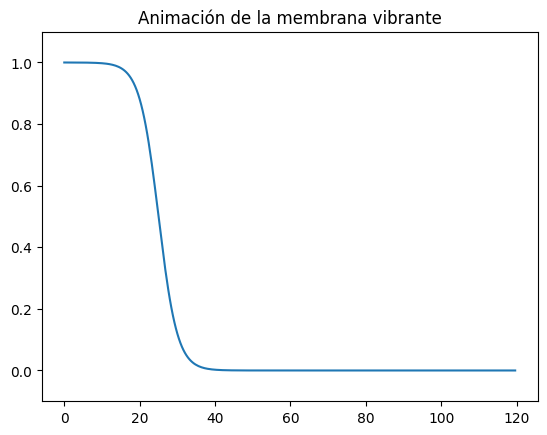

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

N = 300
dx = 0.4
dt = 0.1
eps = 0.2
mu = 0.1

u_old = np.zeros(N)
u_new = np.zeros(N)

x = np.arange(N)*dx

u = 0.5*(1 - np.tanh(x/5 - 5))
u_old = np.copy(u)

# Animación
fig, ax = plt.subplots()
im = ax.imshow(u, animated=True, cmap='viridis')
plt.colorbar(im)

# Función de actualización para la animación
def update(frame):
    global u, u_prev, u_next
    for i in range(1, N-1):
        for j in range(1, N-1):
            u_next[i,j] = 2*u[i,j] - u_prev[i,j] + r*(u[i+1,j] + u[i-1,j] + u[i,j+1] + u[i,j-1] - 4*u[i,j])
    
    # Bordes fijos
    u_next[0,:] = 0
    u_next[-1,:] = 0
    u_next[:,0] = 0
    u_next[:,-1] = 0

    u_prev = np.copy(u)
    u = np.copy(u_next)
    im.set_data(u)
    return [im]

ani = FuncAnimation(fig, update, frames=300, interval=30)
plt.title('Animación de la membrana vibrante')
plt.show()